In [1]:
import numpy as np
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import xgboost
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from IPython.display import clear_output
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [2]:
df = pd.read_csv(r"C:\PREDICTINGMATERNALHEALTHRISK\predicting-maternal-health-risk\data\01_raw\Maternal Health Risk Data Set.csv")

In [3]:
df.head(5)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
df.tail(5)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [5]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [6]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

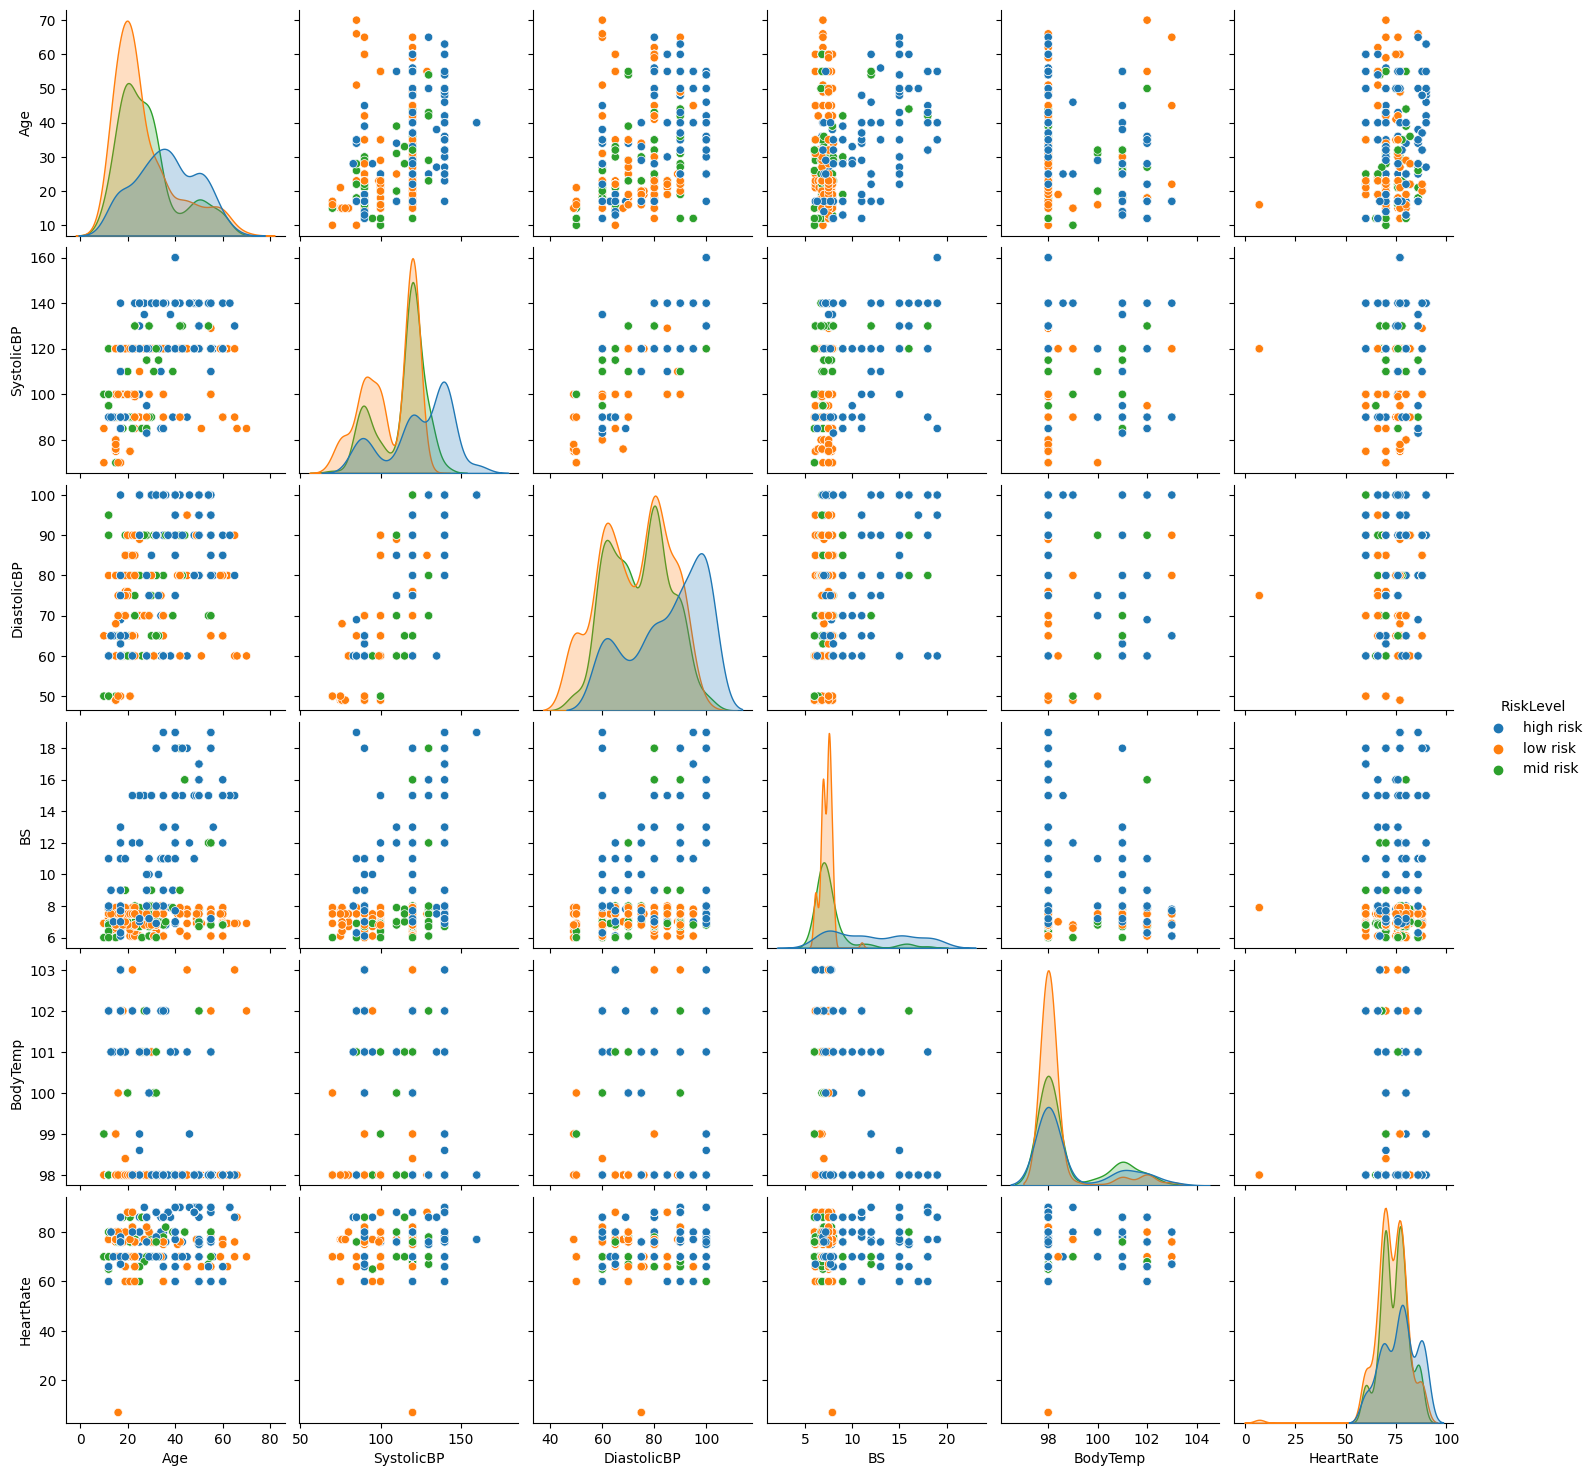

In [8]:
sns.pairplot(df, hue="RiskLevel")
plt.show()

In [9]:
# Encode RiskLevel first
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel'] = df['RiskLevel'].map(risk_mapping)

# Now split
X_dev = df.iloc[:, :-1]
y_dev = df.iloc[:, -1].astype(int)  # ensure integer type

# Verify
print("Number of each label in the dataset:")
print(np.unique(y_dev, return_counts=True))
# Should show: (array([0, 1, 2]), array([406, 336, 272]))

Number of each label in the dataset:
(array([0, 1, 2]), array([406, 336, 272]))


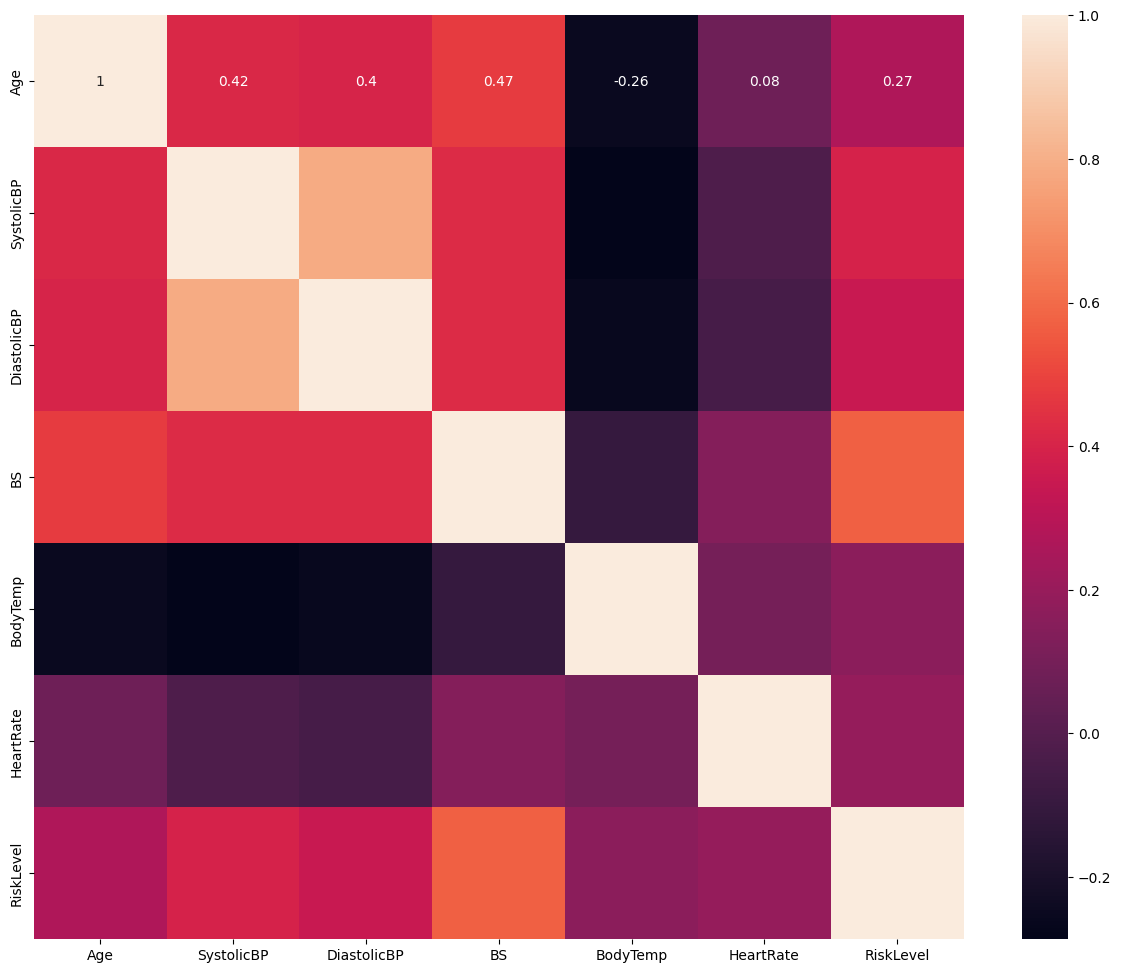

In [10]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True)
plt.show()

Mean Accuracy : 0.7918
Std Accuracy  : 0.1267


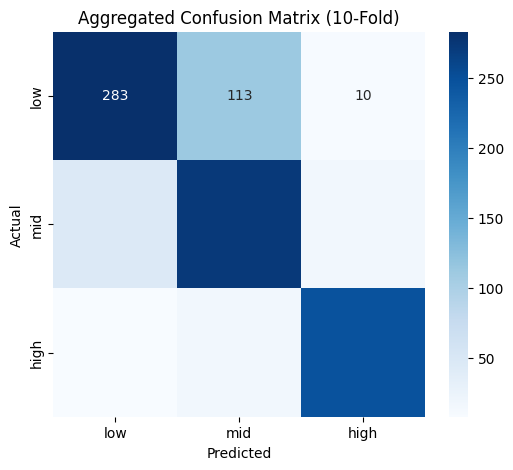

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

skf = StratifiedKFold(n_splits=10)
accuracies = []
final_cm = np.zeros((3, 3), dtype=int)  # 3 classes

for train_index, val_index in skf.split(X_dev, y_dev):
    X_train, X_val = X_dev.iloc[train_index], X_dev.iloc[val_index]
    y_train, y_val = y_dev[train_index], y_dev[val_index]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    xgb_model = xgboost.XGBClassifier(
        n_estimators=750,
        max_depth=7,
        eta=0.1,
        subsample=0.3,
        colsample_bytree=0.4,
        objective="multi:softmax",
        num_class=3,
        verbosity=0
    )
    xgb_model.fit(X_train_scaled, y_train)
    y_val_hat = xgb_model.predict(X_val_scaled)

    acc = accuracy_score(y_val, y_val_hat)
    accuracies.append(acc)
    final_cm += confusion_matrix(y_val, y_val_hat, labels=[0, 1, 2])

# Summary
print(f"Mean Accuracy : {np.mean(accuracies):.4f}")
print(f"Std Accuracy  : {np.std(accuracies):.4f}")

# Single aggregated confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'mid', 'high'],
            yticklabels=['low', 'mid', 'high'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Aggregated Confusion Matrix (10-Fold)')
plt.show()

In [14]:
from tensorflow.keras.layers import Input

def neural_network(input_dim, output_dim, dropout_frac=0.2, number_neurons1=512, number_neurons2=1024, number_neurons3=512):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))          # replaces input_dim= argument
    model.add(Dense(units=number_neurons1, activation='relu'))
    model.add(Dropout(dropout_frac)) ## Prevents Overfitting
    model.add(Dense(units=number_neurons2, activation='relu'))
    model.add(Dropout(dropout_frac))
    model.add(Dense(units=number_neurons3, activation='relu'))
    model.add(Dropout(dropout_frac))
    model.add(Dense(units=output_dim, activation='softmax'))
    model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
    return model

In [15]:
class PlotLosses(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.plot(self.x, self.losses, label="loss")
        plt.plot(self.x, self.val_losses, label="val_loss")
        plt.legend()
        plt.show()

plot_losses = PlotLosses()

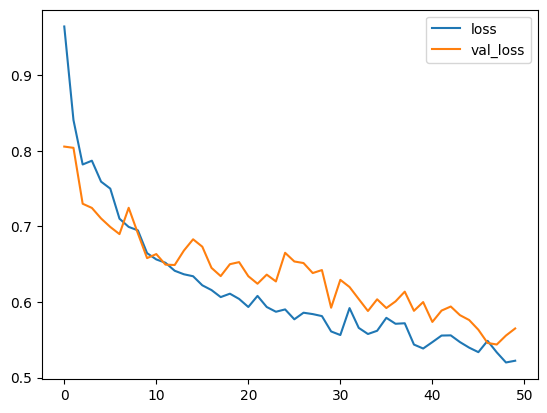

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
NN Mean Accuracy : 0.6972
NN Std Accuracy  : 0.0726


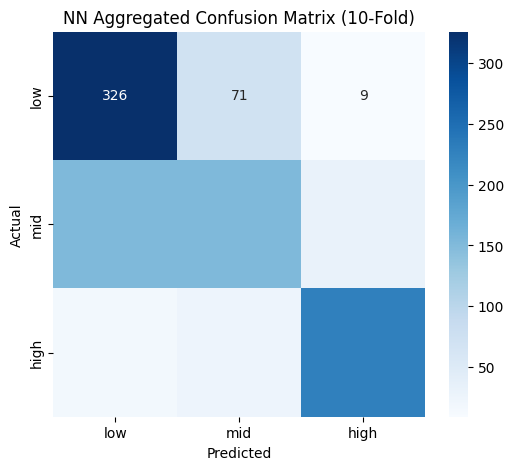

In [16]:
skf = StratifiedKFold(n_splits=10)
accuracies_nn = []
final_cm_nn = np.zeros((3, 3), dtype=int)

for train_index, val_index in skf.split(X_dev, y_dev):
    X_train, X_val = X_dev.iloc[train_index], X_dev.iloc[val_index]
    y_train, y_val = y_dev[train_index], y_dev[val_index]

    # One-hot for NN
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_val_cat   = tf.keras.utils.to_categorical(y_val,   num_classes=3)

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    model = neural_network(input_dim=X_train_scaled.shape[1], output_dim=3)
    model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=50,
        verbose=0,
        callbacks=[plot_losses]
    )

    y_val_hat = np.argmax(model.predict(X_val_scaled), axis=1)
    acc = accuracy_score(y_val, y_val_hat)
    accuracies_nn.append(acc)
    final_cm_nn += confusion_matrix(y_val, y_val_hat, labels=[0, 1, 2])

# Summary
print(f"NN Mean Accuracy : {np.mean(accuracies_nn):.4f}")
print(f"NN Std Accuracy  : {np.std(accuracies_nn):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(final_cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low', 'mid', 'high'],
            yticklabels=['low', 'mid', 'high'])
plt.title('NN Aggregated Confusion Matrix (10-Fold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
import joblib

# Save
xgb_model.save_model('../data/06_models/xgboost_model.json')

# Load back
xgb_model = xgboost.XGBClassifier()
xgb_model.load_model('../data/06_models/xgboost_model.json')

In [21]:
# Save (save the last fold's model, or the best one)
model.save('../data/06_models/nn_model.keras')

# Load back
from tensorflow.keras.models import load_model
nn_model = load_model('../data/06_models/nn_model.keras')